# 🏡 House Sales Analysis

### Overview

In this notebook, I performed **Exploratory Data Analysis (EDA)** on the **House Sales in King County, USA** dataset using **NumPy, Pandas, Matplotlib, and Seaborn**.

###  Objective

-  Explore the dataset
-  Find patterns and relationships
-  Understand the factors affecting house prices
-  Visualize the data using different plots


#  Column Guide

- **price** – Selling price of the house.
- **bedrooms** – Number of bedrooms.
- **bathrooms** – Number of bathrooms.
- **sqft_living** – Total living area (in square feet).
- **sqft_lot** – Total land area (in square feet).
- **floors** – Number of floors.
- **waterfront** – Whether the house has a waterfront view (0 = No, 1 = Yes).
- **view** – Quality of the view from the house.
- **condition** – Overall condition of the house.
- **grade** – Construction and design quality of the house.
- **sqft_above** – Living area above ground level.
- **sqft_basement** – Basement area.
- **yr_built** – Year the house was built.
- **yr_renovated** – Year the house was renovated (0 means not renovated).
- **zipcode** – ZIP code of the house.
- **lat** – Latitude of the house.
- **long** – Longitude of the house.
- **sqft_living15** – Average living area of nearby houses.
- **sqft_lot15** – Average lot size of nearby houses.

## Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path='/kaggle/input/datasets/harlfoxem/housesalesprediction/kc_house_data.csv'
df=pd.read_csv(path)

## Data Observation

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.shape

(21613, 21)

In [5]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [6]:
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [7]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df=df.drop(columns='id')

### Removing the `id` Column

The `id` column is just a unique identifier for each house. It does not provide any useful information for predicting house prices. Therefore, I removed this column before further analysis and model training.

In [11]:
df['date']=pd.to_datetime(df['date'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           21613 non-null  datetime64[ns]
 1   price          21613 non-null  float64       
 2   bedrooms       21613 non-null  int64         
 3   bathrooms      21613 non-null  float64       
 4   sqft_living    21613 non-null  int64         
 5   sqft_lot       21613 non-null  int64         
 6   floors         21613 non-null  float64       
 7   waterfront     21613 non-null  int64         
 8   view           21613 non-null  int64         
 9   condition      21613 non-null  int64         
 10  grade          21613 non-null  int64         
 11  sqft_above     21613 non-null  int64         
 12  sqft_basement  21613 non-null  int64         
 13  yr_built       21613 non-null  int64         
 14  yr_renovated   21613 non-null  int64         
 15  zipcode        2161

## Univariate Analysis


### Price Column

The histogram below shows how house prices are distributed in the dataset.

<Axes: ylabel='Frequency'>

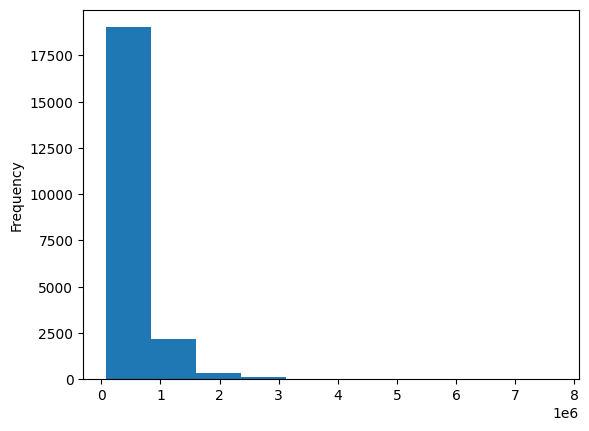

In [13]:
df['price'].plot(kind='hist')

<Axes: >

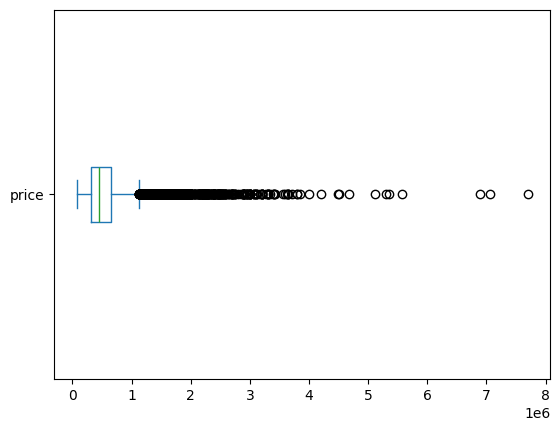

In [14]:
df['price'].plot(kind='box',vert=False)

In [15]:
df[df['price']>5000000]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1164,2014-10-20,5110800.0,5,5.25,8010,45517,2.0,1,4,3,12,5990,2020,1999,0,98033,47.6767,-122.211,3430,26788
1315,2015-04-13,5300000.0,6,6.00,7390,24829,2.0,1,4,4,12,5000,2390,1991,0,98040,47.5631,-122.210,4320,24619
1448,2015-04-13,5350000.0,5,5.00,8000,23985,2.0,0,4,3,12,6720,1280,2009,0,98004,47.6232,-122.220,4600,21750
3914,2014-06-11,7062500.0,5,4.50,10040,37325,2.0,1,2,3,11,7680,2360,1940,2001,98004,47.6500,-122.214,3930,25449
4411,2014-08-04,5570000.0,5,5.75,9200,35069,2.0,0,0,3,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
7252,2014-10-13,7700000.0,6,8.00,12050,27600,2.5,0,3,4,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
9254,2014-09-19,6885000.0,6,7.75,9890,31374,2.0,0,4,3,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730


## Price Column Analysis
- Distribution is right skewed
- Outliers are present
- High prices houses are present in real world.

### sqft_living Column

The charts below show the distribution of house living area and help identify possible outliers.

<Axes: ylabel='Frequency'>

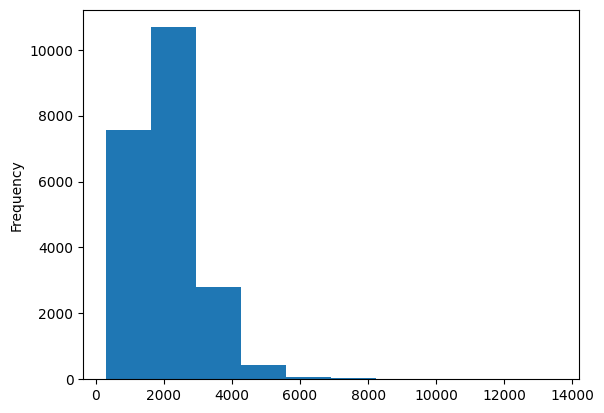

In [16]:
df['sqft_living'].plot(kind='hist')

<Axes: >

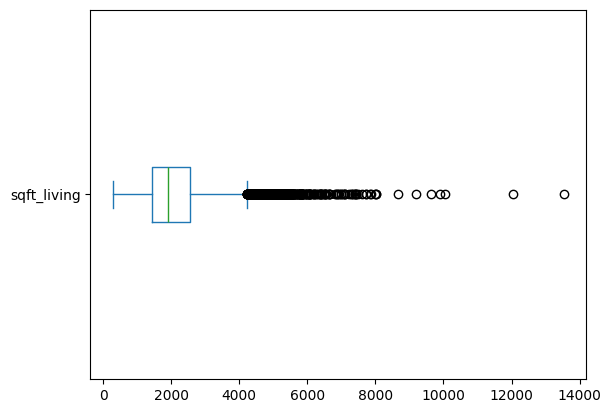

In [17]:
df['sqft_living'].plot(kind='box',vert=False)

In [18]:
df[df['sqft_living']>12000]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
7252,2014-10-13,7700000.0,6,8.0,12050,27600,2.5,0,3,4,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
12777,2014-05-05,2280000.0,7,8.0,13540,307752,3.0,0,4,3,12,9410,4130,1999,0,98053,47.6675,-121.986,4850,217800


## sqft living Column Analysis-

- Most houses have a living area between **1,000 and 3,000 sq ft**.
- The data is **right-skewed**, which means only a few houses have a very large living area.
- The box plot shows some **outliers**.
- After checking these outliers, I found that only **2 houses** have a living area greater than **12,000 sq ft**.
- These are real houses, so I decided to **keep them** in the dataset.

### Floors Column

The charts below show the distribution of the number of floors in the houses.


<Axes: ylabel='Frequency'>

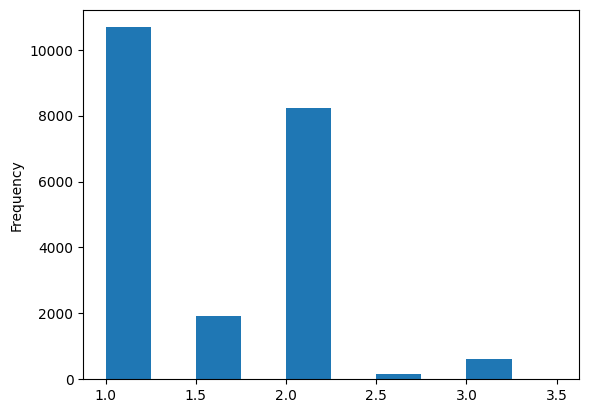

In [19]:
df['floors'].plot(kind='hist')

<Axes: xlabel='floors'>

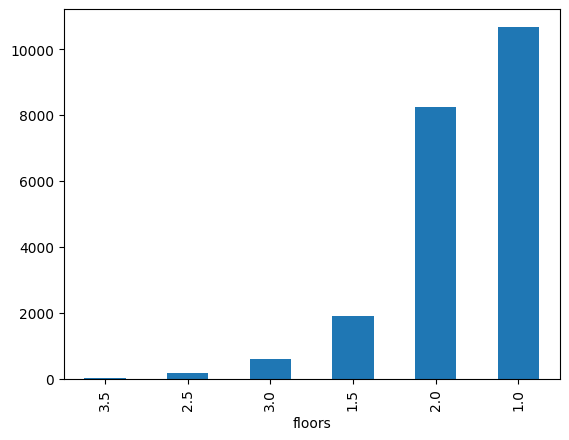

In [20]:
df['floors'].value_counts().sort_values().plot(kind='bar')

## Floor Column Analysis-
- Most houses have **1 or 2 floors**.
- Very few houses have **2.5, 3, or 3.5 floors**.
- This shows that **single-floor and double-floor houses are the most common** in this dataset.
- Houses with more than **2 floors are rare**.

### Bedrooms Column

Let's explore how the number of bedrooms is distributed across the houses in the dataset.


<Axes: ylabel='Frequency'>

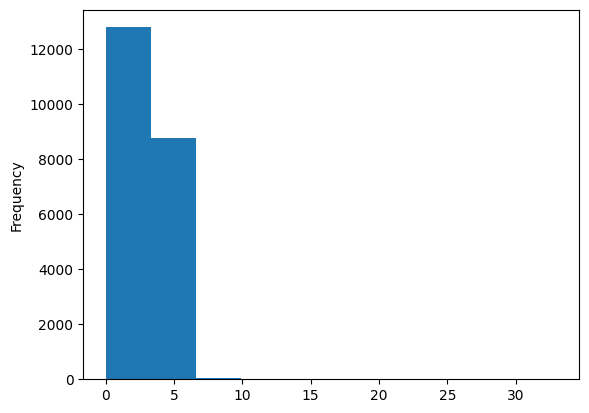

In [21]:
df['bedrooms'].plot(kind='hist')

<Axes: >

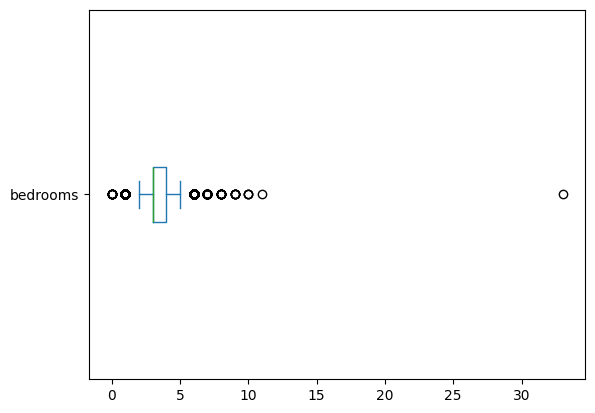

In [22]:
df['bedrooms'].plot(kind='box',vert=False)

In [23]:
df[df['bedrooms']>12]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15870,2014-06-25,640000.0,33,1.75,1620,6000,1.0,0,0,5,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


In [24]:
df=df[df['bedrooms']<33]

<Axes: xlabel='bedrooms'>

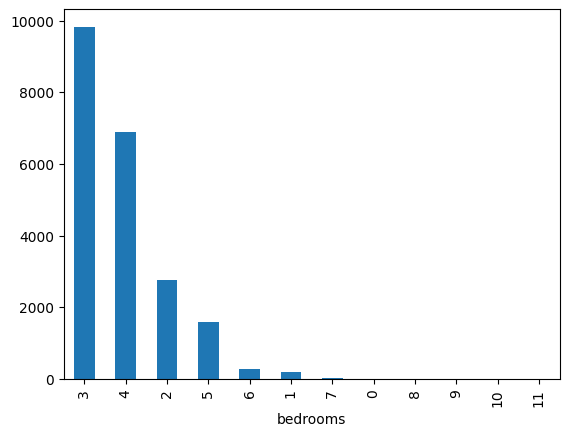

In [25]:
df['bedrooms'].value_counts().sort_values(ascending=False).plot(kind='bar')

## Bedroom Column Analysis
- One house had 33 bedrooms, which is very unusual because all other houses have 11 or fewer bedrooms. After checking its price and living area, it looked like a data entry mistake. So, I removed this record to avoid incorrect analysis.

## Bathrooms Column

The charts Shows the Distribution of Bathrooms Column

<Axes: ylabel='Frequency'>

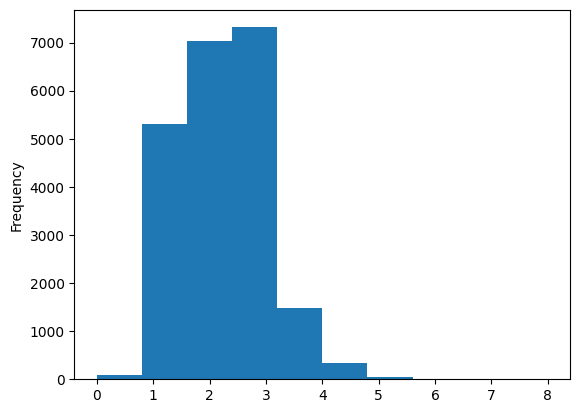

In [26]:
df['bathrooms'].plot(kind='hist')

<Axes: >

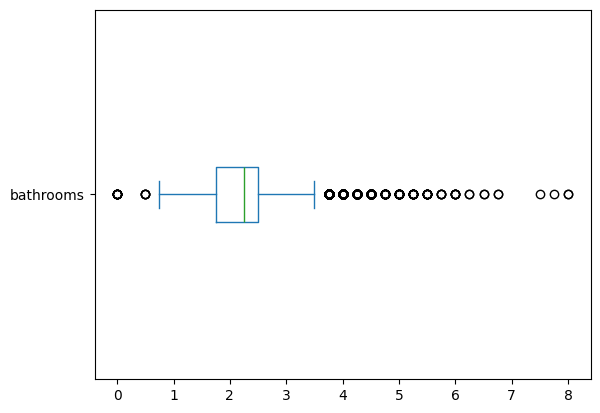

In [27]:
df['bathrooms'].plot(kind='box',vert=False)

In [28]:
df[df['bathrooms']>7]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
7252,2014-10-13,7700000.0,6,8.00,12050,27600,2.5,0,3,4,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
8546,2014-08-11,450000.0,9,7.50,4050,6504,2.0,0,0,3,7,4050,0,1996,0,98144,47.5923,-122.301,1448,3866
9254,2014-09-19,6885000.0,6,7.75,9890,31374,2.0,0,4,3,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730
12777,2014-05-05,2280000.0,7,8.00,13540,307752,3.0,0,4,3,12,9410,4130,1999,0,98053,47.6675,-121.986,4850,217800


## Bathrooms Column Analysis-
- Most houses have **2 to 3 bathrooms**.
- Only **4 houses have more than 7 bathrooms**, making them rare outliers.
- These houses are much larger and more luxurious than typical houses in the dataset.

## sqft_lot Column
- Below is the distribution of sqft_lot Column

<Axes: ylabel='Frequency'>

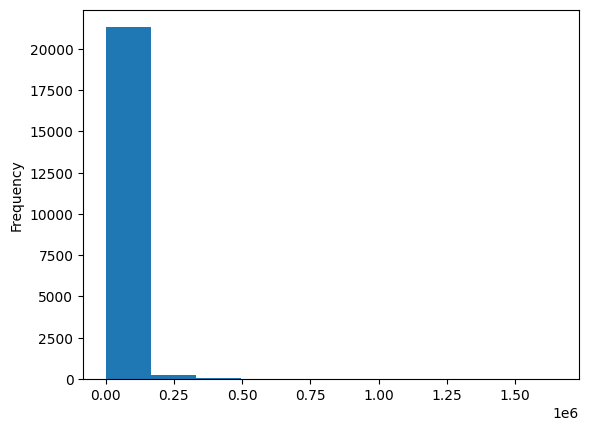

In [29]:
df['sqft_lot'].plot(kind='hist')

<Axes: >

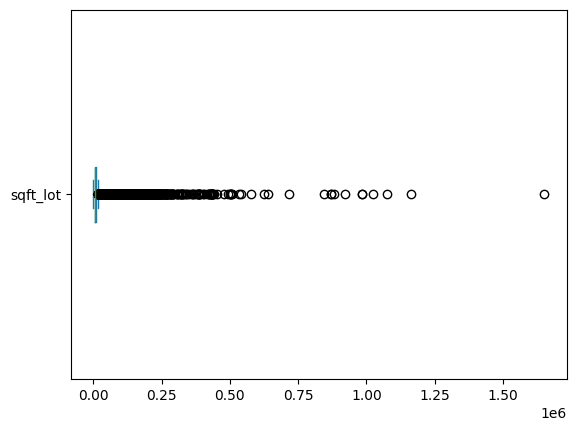

In [30]:
df['sqft_lot'].plot(kind='box',vert=False)

In [31]:
df[df['sqft_lot']>1025000]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1719,2015-03-27,700000.0,4,1.00,1300,1651359,1.0,0,3,4,6,1300,0,1920,0,98022,47.2313,-122.023,2560,425581
7647,2014-05-21,542500.0,5,3.25,3010,1074218,1.5,0,0,5,8,2010,1000,1931,0,98027,47.4564,-122.004,2450,68825
17319,2015-05-04,190000.0,2,1.00,710,1164794,1.0,0,0,2,5,710,0,1915,0,98014,47.6888,-121.909,1680,16730


## sqft_lot Column

- Only **3 houses** have an extremely large lot size.
- These are rare outliers in the dataset.
- A larger lot size does not always mean a higher house price.

## sqft_above Column

<Axes: ylabel='Frequency'>

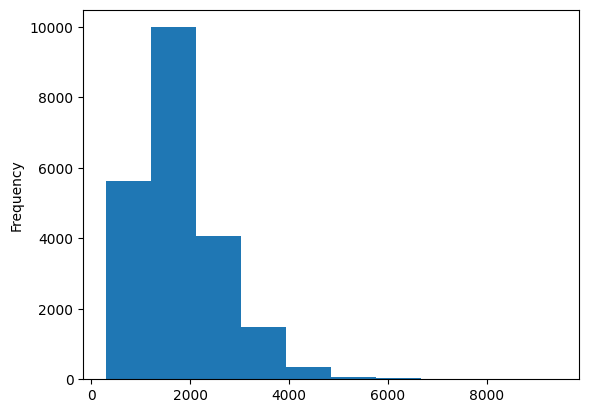

In [32]:
df['sqft_above'].plot(kind='hist')

<Axes: >

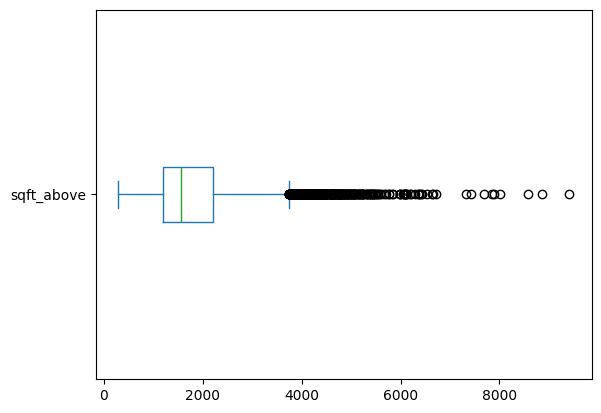

In [33]:
df['sqft_above'].plot(kind='box',vert=False)

In [34]:
df[df['sqft_above']>8000]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
7252,2014-10-13,7700000.0,6,8.00,12050,27600,2.5,0,3,4,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
9254,2014-09-19,6885000.0,6,7.75,9890,31374,2.0,0,4,3,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730
12777,2014-05-05,2280000.0,7,8.00,13540,307752,3.0,0,4,3,12,9410,4130,1999,0,98053,47.6675,-121.986,4850,217800
18302,2014-07-02,3300000.0,5,6.25,8020,21738,2.0,0,0,3,11,8020,0,2001,0,98006,47.5675,-122.189,4160,18969


## sqft_above Column Analysis
- Only **4 houses** have more than **8,000 sq ft** of above-ground living area.
- These are rare luxury houses in the dataset.
- Most of these houses also have very high selling prices.

## sqft_basement Column

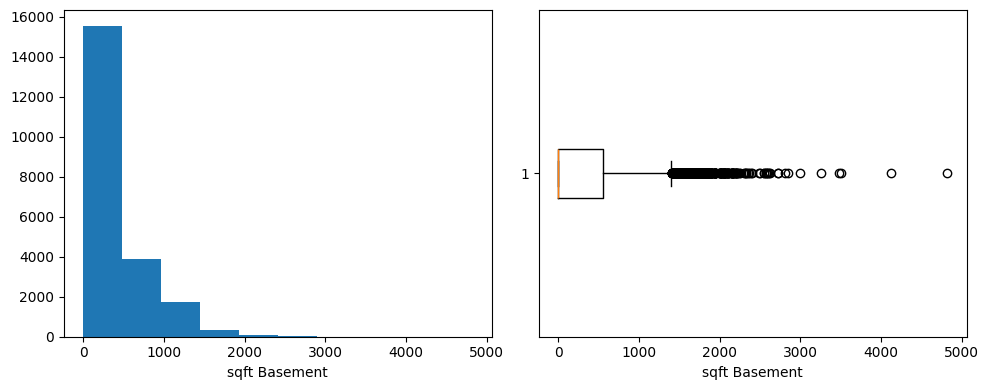

In [35]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].hist(x=df['sqft_basement'])
ax[0].set_xlabel('sqft Basement')
ax[1].boxplot(x=df['sqft_basement'],vert=False)
ax[1].set_xlabel('sqft Basement')
plt.tight_layout()
plt.show()

In [36]:
df[df['sqft_basement']>4000]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
8092,2014-06-17,4668000.0,5,6.75,9640,13068,1.0,1,4,3,12,4820,4820,1983,2009,98040,47.5570,-122.210,3270,10454
12777,2014-05-05,2280000.0,7,8.00,13540,307752,3.0,0,4,3,12,9410,4130,1999,0,98053,47.6675,-121.986,4850,217800


## sqft_basement Column Analysis
- Only **2 houses** have a basement area greater than **4,000 sq ft**.
- These are very rare houses in the dataset.
- Both houses have a large living area and high selling prices.

## Grade Column

<Axes: xlabel='grade'>

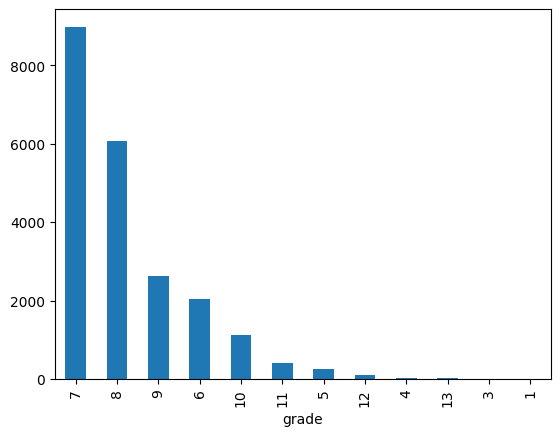

In [37]:
df['grade'].value_counts().plot(kind='bar')

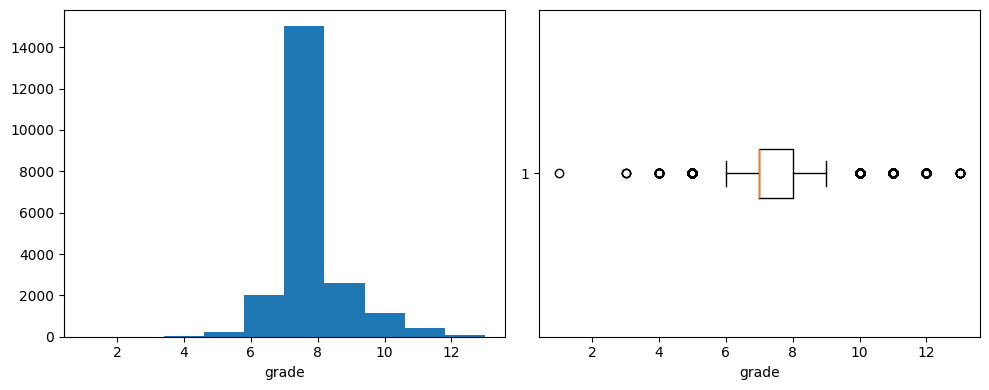

In [38]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].hist(x=df['grade'])
ax[0].set_xlabel('grade')
ax[1].boxplot(x=df['grade'],vert=False)
ax[1].set_xlabel('grade')
plt.tight_layout()
plt.show()

In [39]:
df[df['grade']<2]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
19452,2014-09-26,142000.0,0,0.0,290,20875,1.0,0,0,1,1,290,0,1963,0,98024,47.5308,-121.888,1620,22850


In [40]:
df[df['grade']>=13]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
4411,2014-08-04,5570000.0,5,5.75,9200,35069,2.0,0,0,3,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
4811,2015-03-04,2479000.0,5,3.75,6810,7500,2.5,0,0,3,13,6110,700,1922,0,98102,47.6285,-122.322,2660,7500
5451,2014-10-10,1780000.0,4,3.25,4890,13402,2.0,0,0,3,13,4890,0,2004,0,98059,47.5303,-122.131,5790,13539
6041,2014-11-20,2385000.0,4,4.00,6330,13296,2.0,0,2,3,13,4900,1430,2000,0,98033,47.6488,-122.201,2200,9196
7035,2014-07-01,3800000.0,5,5.50,7050,42840,1.0,0,2,4,13,4320,2730,1978,0,98004,47.6229,-122.220,5070,20570
7252,2014-10-13,7700000.0,6,8.00,12050,27600,2.5,0,3,4,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
7907,2014-09-23,3200000.0,6,5.00,7100,18200,2.5,0,0,3,13,5240,1860,1933,2002,98199,47.6427,-122.408,3130,6477
9254,2014-09-19,6885000.0,6,7.75,9890,31374,2.0,0,4,3,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730
10373,2014-12-12,2983000.0,5,5.50,7400,18898,2.0,0,3,3,13,6290,1110,2001,0,98006,47.5431,-122.112,6110,26442
13411,2015-01-30,2415000.0,5,4.75,7880,24250,2.0,0,2,3,13,7880,0,1996,0,98177,47.7334,-122.362,2740,10761


## Grade Column


The boxplot shows a few outliers for Grade 1 and Grade 13. Instead of removing them, I checked the actual records.

The house with **Grade 1** has a very low price, very small living area, and almost no bedrooms or bathrooms. This information is consistent, so it does not appear to be a data entry error.

The houses with **Grade 13** have high prices, large living areas, more bedrooms and bathrooms, and represent luxury homes. These values also look realistic.

Since both the lower and higher grade values are valid, I decided to keep all the records in the dataset.

## View Column


<Axes: xlabel='view'>

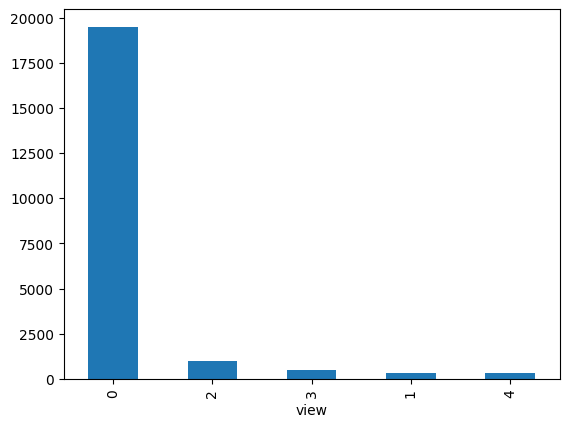

In [41]:
df['view'].value_counts().plot(kind='bar')

<Axes: >

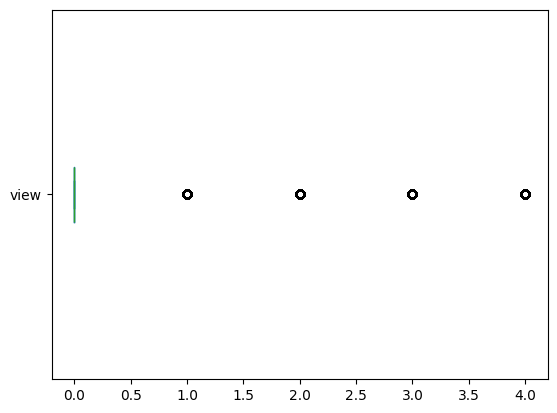

In [42]:
df['view'].plot(kind='box',vert=False)

In [43]:
df[df['view']>=3]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15,2015-01-24,650000.0,4,3.00,2950,5000,2.0,0,3,3,9,1980,970,1979,0,98126,47.5714,-122.375,2140,4000
21,2014-08-26,2000000.0,3,2.75,3050,44867,1.0,0,4,3,9,2330,720,1968,0,98040,47.5316,-122.233,4110,20336
58,2014-08-27,951000.0,5,3.25,3250,14342,2.0,0,4,4,8,3250,0,1968,0,98008,47.5880,-122.116,2960,11044
60,2014-12-10,650000.0,3,2.25,2150,21235,1.0,0,3,4,8,1590,560,1959,0,98166,47.4336,-122.339,2570,18900
114,2014-10-28,480000.0,4,2.50,3230,16171,2.0,0,3,3,9,2520,710,2001,0,98001,47.3183,-122.253,2640,8517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21344,2014-08-22,1488000.0,5,6.00,6880,279968,2.0,0,3,3,12,4070,2810,2007,0,98045,47.4624,-121.779,4690,256803
21505,2014-06-17,1555000.0,3,3.50,4360,6240,2.0,0,3,3,10,2960,1400,2008,0,98103,47.6791,-122.354,1920,3910
21539,2015-02-19,338500.0,3,2.25,1333,1470,3.0,0,3,3,7,1333,0,2009,0,98125,47.7058,-122.302,1360,1680
21540,2015-01-13,1881580.0,5,3.50,4410,13000,2.0,0,3,3,10,2920,1490,2014,0,98006,47.5382,-122.111,5790,12969


## View Column

The boxplot marks the higher view values (3 and 4) as outliers because most houses in the dataset have a view value of 0. However, these are not data errors.

After checking the records, I found that houses with higher view ratings generally have higher prices. This makes sense because houses with better views are usually more expensive.

Since these values are valid and provide useful information about the house, I decided to keep all the records in the dataset.

### Waterfront Column

<Axes: xlabel='waterfront'>

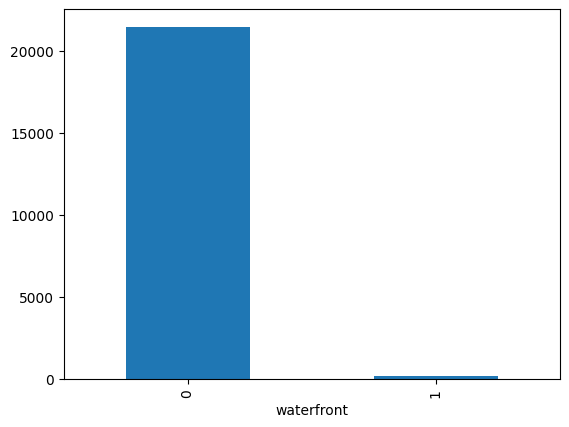

In [44]:
df['waterfront'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

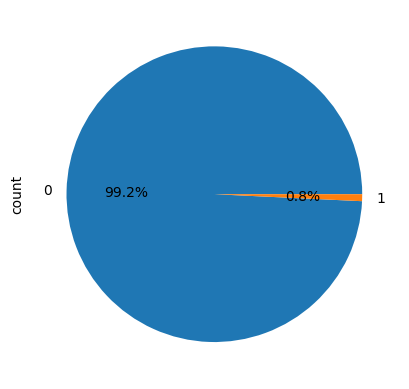

In [45]:
((df['waterfront'].value_counts()*100)/len(df['waterfront'])).plot(kind='pie',autopct='%0.1f%%')

### Waterfront Column Analysis

The `waterfront` column is a binary feature where:
- 0 = House does not have a waterfront.
- 1 = House has a waterfront.

From the distribution, around **99.2%** of the houses do not have a waterfront, while only **0.8%** have one.

This shows that waterfront houses are very rare in the dataset.

## Condition Column

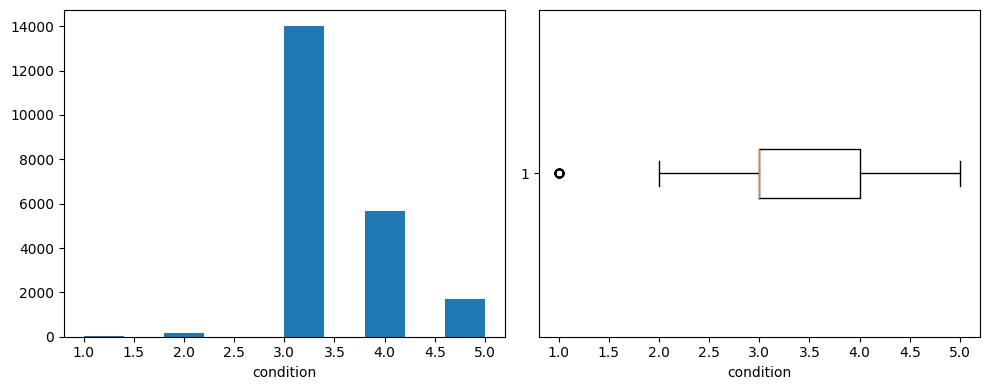

In [46]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].hist(x=df['condition'])
ax[0].set_xlabel('condition')
ax[1].boxplot(x=df['condition'],vert=False)
ax[1].set_xlabel('condition')
plt.tight_layout()
plt.show()

In [47]:
df[df['condition']<=1]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
36,2014-05-28,550000.0,4,1.00,1660,34848,1.0,0,0,1,5,930,730,1933,0,98052,47.6621,-122.132,2160,11467
380,2014-09-16,270000.0,2,1.50,1380,209959,1.0,0,0,1,6,1380,0,1954,0,98011,47.7461,-122.195,3130,19868
397,2014-06-23,365000.0,4,2.00,1940,25600,1.0,0,0,1,8,1940,0,1962,0,98006,47.5722,-122.129,2000,10071
1442,2014-11-07,352950.0,3,1.00,1760,3000,1.5,0,0,1,6,1760,0,1900,0,98103,47.6598,-122.348,1320,1266
1734,2015-01-02,252000.0,1,1.00,680,1638,1.0,0,4,1,6,680,0,1910,1992,98116,47.5832,-122.399,1010,3621
2223,2015-03-16,535000.0,2,1.00,920,9000,1.0,0,0,1,6,920,0,1954,0,98033,47.6831,-122.189,1760,8400
3004,2014-12-31,441000.0,4,1.50,1100,3300,1.0,0,0,1,7,1100,0,1919,0,98122,47.6033,-122.295,2020,4000
3202,2014-05-09,255000.0,2,1.00,810,7980,1.0,0,0,1,6,810,0,1928,0,98146,47.4890,-122.337,1440,7980
3975,2015-05-11,210000.0,2,1.00,990,8140,1.0,0,0,1,6,990,0,1910,0,98116,47.5828,-122.382,2150,5000
4651,2014-10-02,125000.0,1,1.00,500,7440,1.0,0,0,1,5,500,0,1928,0,98106,47.5252,-122.362,1350,7440


## Condition Column Analysis

The boxplot marks houses with **condition = 1** as outliers because very few houses have this condition.

To verify this, I checked all houses with `condition = 1`. There are many such records, and they have realistic values for price, bedrooms, bathrooms, and other features.

This shows that these are not data entry errors. They simply represent houses in very poor condition.

**Conclusion:** Although the boxplot identifies them as outliers, they are valid observations and will be kept in the dataset.

## yr_built Column

In [48]:
df['yr_built'].nunique()

116

<Axes: >

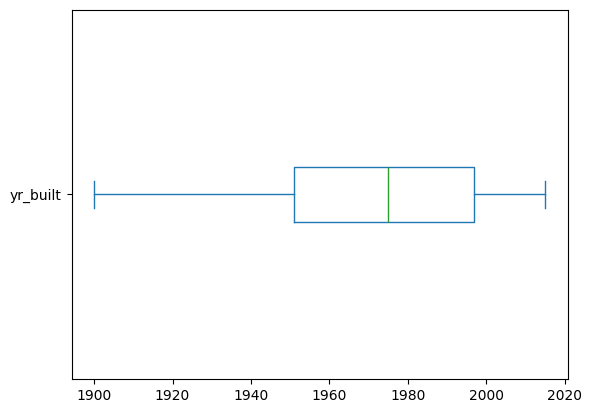

In [49]:
df['yr_built'].plot(kind='box',vert=False)

## yr_built Column Analysis

The `yr_built` column contains the year in which each house was built.

The boxplot does not show any outliers, and all the years fall within a realistic range. The dataset contains 116 unique construction years, which is expected since the houses were built over many decades.

**Conclusion:** The `yr_built` column does not contain any invalid values or outliers, so no cleaning is required.

## yr_renovated column

<Axes: >

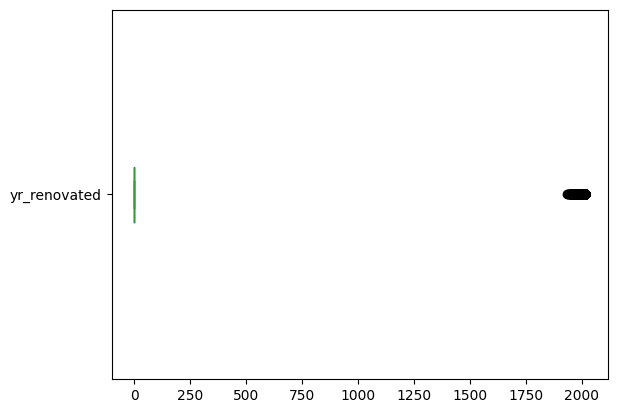

In [50]:
df['yr_renovated'].plot(kind='box',vert=False)

In [51]:
year_renovated=df[df['yr_renovated']>2000]
year_renovated

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
35,2014-06-13,696000.0,3,2.50,2300,3060,1.5,0,0,3,8,1510,790,1930,2002,98115,47.6827,-122.310,1590,3264
103,2014-10-07,1088000.0,3,2.50,2920,8113,2.0,0,0,3,8,2920,0,1950,2010,98004,47.5814,-122.196,2370,8113
158,2014-11-13,247000.0,3,2.00,1270,7198,1.5,0,0,3,7,1270,0,1916,2013,98022,47.2086,-121.996,1160,7198
237,2015-03-20,410000.0,4,1.00,1970,4740,1.5,0,0,3,7,1670,300,1904,2005,98122,47.6136,-122.303,1510,4740
269,2015-05-04,2900000.0,4,3.25,5050,20100,1.5,0,2,3,11,4750,300,1982,2008,98004,47.6312,-122.223,3890,20060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19618,2014-07-12,451000.0,2,1.00,900,6000,1.0,0,0,3,7,900,0,1944,2004,98115,47.6855,-122.289,1460,4800
20057,2014-09-04,434900.0,3,2.00,1520,5040,2.0,0,0,3,7,1520,0,1977,2006,98177,47.7770,-122.362,1860,8710
20444,2015-02-25,500012.0,4,2.50,2400,9612,1.0,0,0,3,8,1230,1170,1962,2009,98059,47.4799,-122.127,2430,5539
20447,2015-02-12,356999.0,3,1.50,1010,1546,2.0,0,0,3,8,1010,0,1971,2014,98144,47.5998,-122.311,1010,1517


<Axes: >

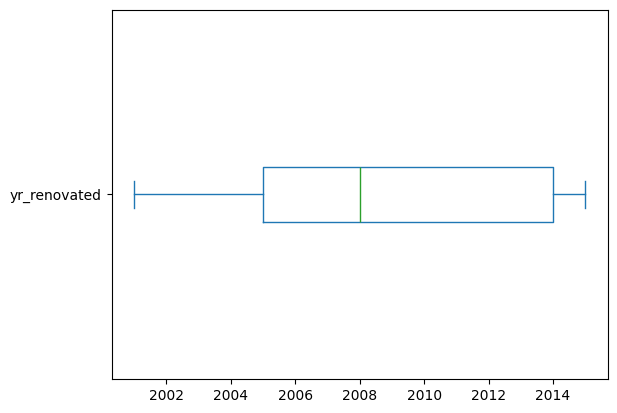

In [52]:
year_renovated['yr_renovated'].plot(kind='box',vert=False)

In [53]:
year_renovated[year_renovated['yr_renovated']<1940]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15


In [54]:
year_renovated[year_renovated['yr_renovated']>2014]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
2295,2014-07-28,585000.0,5,2.75,2350,4178,1.5,0,0,3,8,1520,830,1922,2015,98112,47.6388,-122.300,1920,4178
3156,2015-03-31,830000.0,4,3.00,2020,6000,1.0,0,0,3,8,1220,800,1968,2015,98199,47.6563,-122.401,1400,6000
4240,2015-03-27,815000.0,6,3.00,2860,17853,1.0,0,0,3,8,1430,1430,1962,2015,98006,47.5460,-122.175,1920,13452
5683,2015-03-05,335000.0,3,2.00,1210,9926,1.0,0,0,4,7,1210,0,1954,2015,98006,47.5731,-122.135,1690,9737
7097,2014-10-28,285000.0,4,3.50,2770,10505,2.0,0,0,3,8,2770,0,1940,2015,98133,47.7412,-122.355,1760,10505
7417,2015-01-23,459000.0,4,3.00,1900,9077,2.0,0,0,3,7,1900,0,1954,2015,98155,47.7684,-122.304,1900,12868
7958,2015-03-29,203000.0,3,1.75,1190,6000,1.0,0,0,3,7,1190,0,1952,2015,98178,47.5026,-122.236,1200,6000
8692,2015-05-06,1485000.0,6,2.75,4430,6440,2.0,0,3,3,10,2680,1750,1964,2015,98118,47.5462,-122.265,3530,7314
11599,2014-05-22,850000.0,4,3.25,3090,6744,2.0,0,4,3,9,3090,0,1923,2015,98177,47.7680,-122.388,2020,6656
11633,2015-04-06,717000.0,3,1.00,1150,5000,1.0,0,0,3,8,1150,0,1959,2015,98117,47.6805,-122.369,1160,5000


In [55]:
no_renovated_houses=(df['yr_renovated'] == 0).sum()
print(f'{no_renovated_houses} houses were never renovated')

20698 houses were never renovated


## yr_renovated column analysis

There are **20,698 houses** where `yr_renovated` is **0**, which means these houses were never renovated.

Only a small number of houses have a renovation year recorded. Therefore, most houses in this dataset have not been renovated.

## Bivariate Analysis

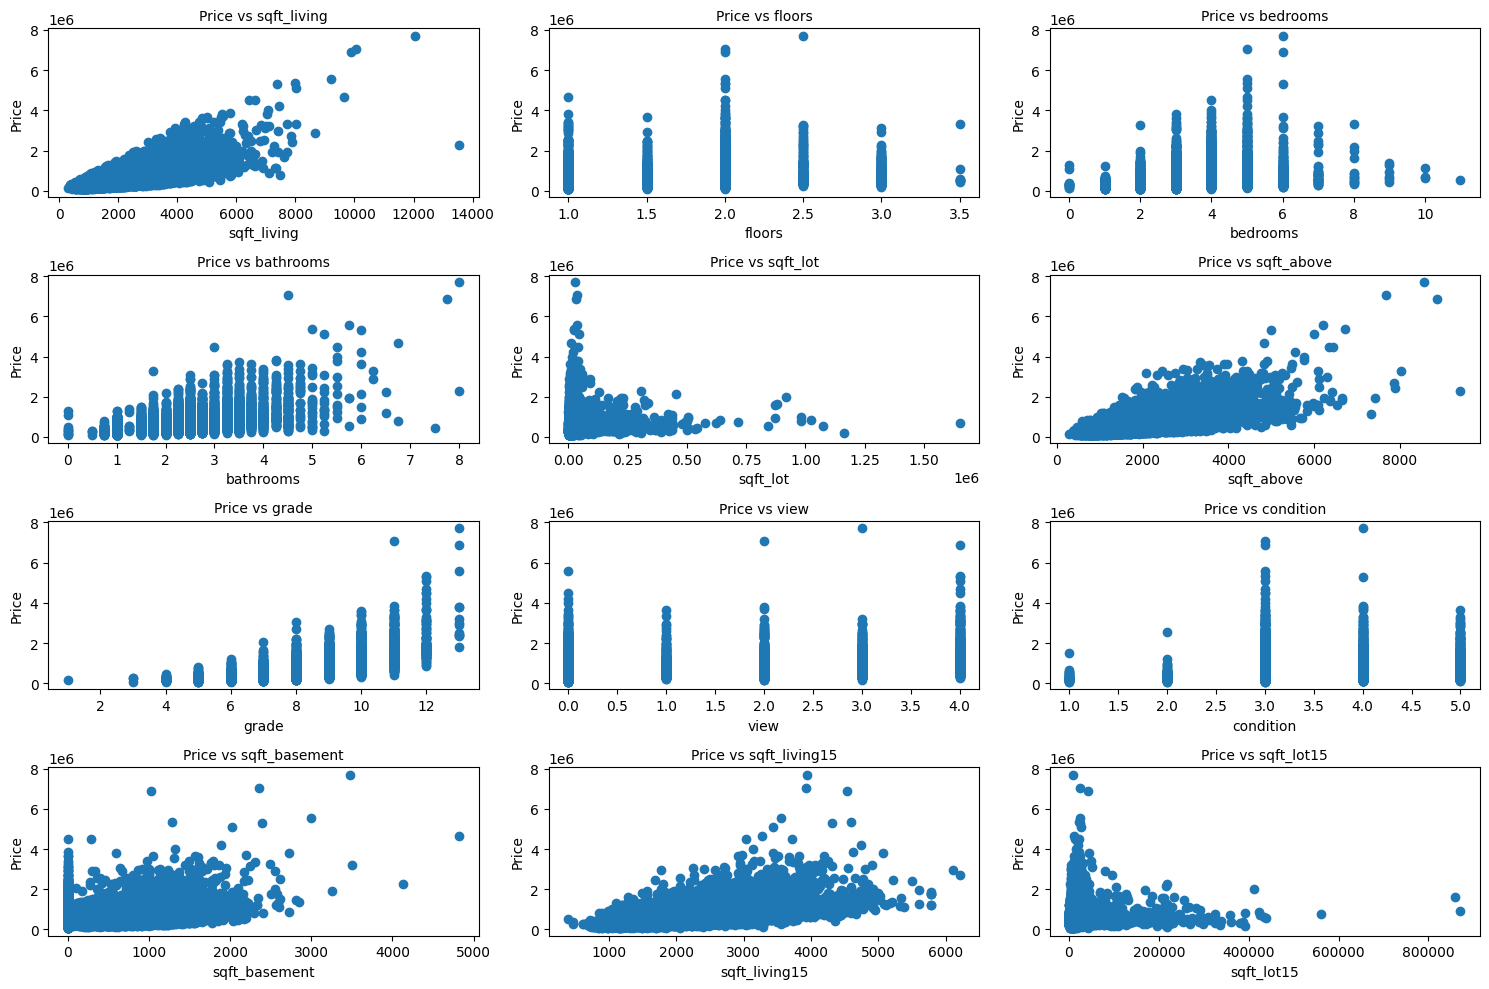

In [56]:
fig,ax=plt.subplots(4,3,figsize=(15,10))
ax[0][0].scatter(x=df['sqft_living'],y=df['price'])
ax[0][1].scatter(x=df['floors'],y=df['price'])
ax[0][2].scatter(x=df['bedrooms'],y=df['price'])
ax[1][0].scatter(x=df['bathrooms'],y=df['price'])
ax[1][1].scatter(x=df['sqft_lot'],y=df['price'])
ax[1][2].scatter(x=df['sqft_above'],y=df['price'])
ax[2][0].scatter(x=df['grade'],y=df['price'])
ax[2][1].scatter(x=df['view'],y=df['price'])
ax[2][2].scatter(x=df['condition'],y=df['price'])
ax[3][0].scatter(df['sqft_basement'], df['price'])
ax[3][1].scatter(df['sqft_living15'], df['price'])
ax[3][2].scatter(df['sqft_lot15'], df['price'])
features = [
    'sqft_living', 'floors', 'bedrooms',
    'bathrooms', 'sqft_lot', 'sqft_above',
    'grade', 'view', 'condition',
    'sqft_basement', 'sqft_living15', 'sqft_lot15'
]

for axis, feature in zip(ax.flat, features):
    axis.set_xlabel(feature)
    axis.set_ylabel('Price')
    axis.set_title(f'Price vs {feature}', fontsize=10)
plt.tight_layout()
plt.show()

<Axes: xlabel='waterfront', ylabel='price'>

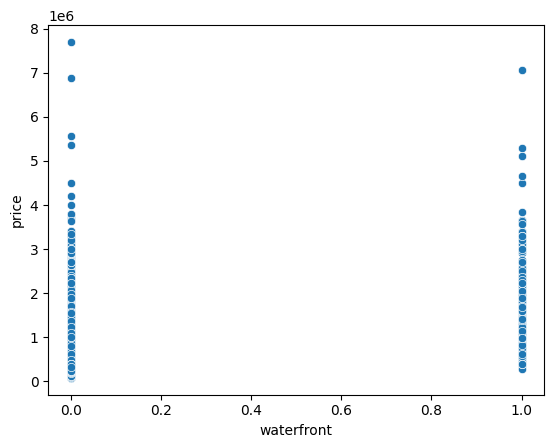

In [57]:
sns.scatterplot(y='price',x='waterfront',data=df)

## Scatter Plots: Price vs Important Features

### Observation

- `sqft_living` has a strong positive relationship with `price`. As the living area increases, the house price generally increases.
- `bathrooms` show a moderate positive relationship with `price`. Houses with more bathrooms tend to have higher prices.
- `sqft_above` also has a strong positive relationship with `price`, indicating that larger above-ground living areas are associated with higher house prices.
- `grade` has a clear positive relationship with `price`. Higher-grade houses generally have higher prices.
- `sqft_basement` shows a positive relationship with `price`, although it is weaker than `sqft_living` and `sqft_above`.
- `sqft_living15` also has a strong positive relationship with `price`, suggesting that houses located in neighborhoods with larger average living areas tend to have higher prices.
- `sqft_lot`, `sqft_lot15`, `floors`, `bedrooms`, `view`, and `condition` show comparatively weaker relationships with `price`. These features may still contribute to the prediction model but are not as influential individually.

### Conclusion

From the scatter plots, the features **`sqft_living`**, **`sqft_above`**, **`grade`**, **`bathrooms`**, **`sqft_basement`**, and **`sqft_living15`** appear to have the strongest relationship with the target variable (`price`). These features are likely to be important predictors while building the house price prediction model.

## Correlation

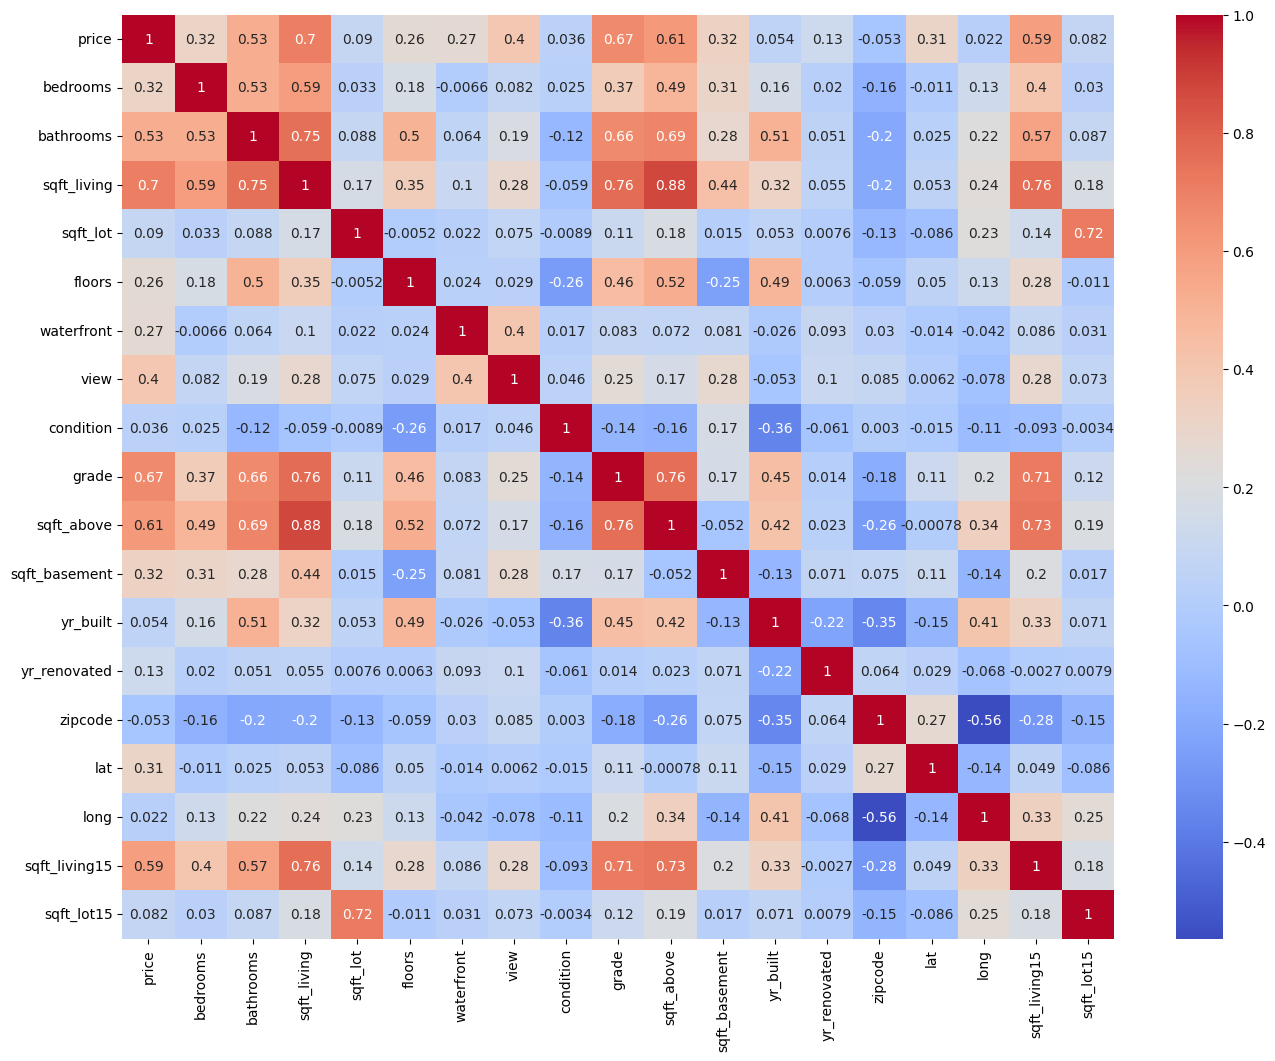

In [58]:
corr_matrix=(
    df.select_dtypes('number').corr()
)
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.savefig('correlation_heatmap.png',dpi=300,bbox_inches='tight')

## Correlation Analysis - Observation

- From the correlation heatmap,**`sqft_living`**, **`sqft_above`**, **`grade`**, **`bathrooms`**, **`sqft_basement`**, and **`sqft_living15`** have the strongest positive correlation with the **price** column.
- This means that as the values of these features increase, the house price generally tends to increase.
- These features appear to have a strong influence on the target variable and are likely to be useful for predicting house prices.
- Therefore, we can use these features while building our machine learning model.

# Final Conclusion

In this notebook, I explored the King County House Sales dataset to better understand the data and the factors that affect house prices.

Some features, such as **`sqft_living`**, **`sqft_above`**, **`grade`**, **`bathrooms`**, **`sqft_basement`**, and **`sqft_living15`**, show a stronger relationship with house prices. Other features, like **`floors`**, **`bedrooms`**, **`condition`**, **`view`**, **`sqft_lot`**, and **`sqft_lot15`**, have a weaker individual relationship.

Overall, this exploratory data analysis helped identify the most important features and provided a better understanding of the dataset. These insights can be useful for building a machine learning model to predict house prices.